# Experimental code for rough segmentation (tree instances) of pointclouds from lidar data.

#### Viggo Trobäck


# Setup the environment

In [25]:
!pip install laspy lazrs numpy pandas matplotlib scipy tqdm scikit-learn open3d

In [26]:
import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.spatial import ConvexHull
from scipy.ndimage import distance_transform_edt
import matplotlib.patches as patches
from tqdm import tqdm
import numpy as np
from sklearn.neighbors import BallTree
from sklearn.cluster import KMeans
import time

print("All packages imported successfully.")

All packages imported successfully.


### Importing selected file
Change this path to any file you want segmented.

In [ ]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if is_colab():
    
    # File loading options
    use_example_data = True  # set to False to upload your own file
    
    if use_example_data:
        !git clone https://github.com/YOURUSERNAME/Tree-segmentation-and-DBH-estimation-from-lidar-data.git
        file = "Tree-segmentation-and-DBH-estimation-from-lidar-data/data/example.las"
    else:
        from google.colab import files
        uploaded = files.upload()
        file = list(uploaded.keys())[0]
else:
    # Running locally
    file = "data/example.las" # change to your local file path

In [14]:
try:
    las = laspy.read(file)
except Exception as e:
    print(f"Error reading LAS file: {e}")

print("Scale factors:", las.header.scale) 
print("Offsets:", las.header.offset)         
print("CRS:", las.header.parse_crs())        # coordinate reference system

# Extract point cloud data
try:
    labels = list(las.point_format.dimension_names)
    if 'classification' in labels:
        print("Classification data is available.")
        print("Classification categories:", np.unique(las.classification))
    points = np.vstack((las.x, las.y, las.z, las.classification)).transpose()

except Exception as e:
    print(f"Error extracting point cloud data: {e}")

# Create a DataFrame for easier manipulation
try:
    df = pd.DataFrame(points, columns=['X', 'Y', 'Z', 'Classification'])
    print(df.head())
except Exception as e:
    print(f"Error creating DataFrame: {e}")

# Normalize to local coordinates (keeps units in meters)
df['X'] = df['X'] - df['X'].min()
df['Y'] = df['Y'] - df['Y'].min()
df['Z'] = df['Z'] - df['Z'].min()

print(df.describe())  # sanity check - X/Y/Z should now start near 0

Scale factors: [0.001 0.001 0.001]
Offsets: [     -0. 6000000.       0.]
CRS: None
Classification data is available.
Classification categories: [2 4 5]
            X            Y    Z  Classification
0  104499.840  6211606.834  0.0             2.0
1  104499.760  6211606.681  0.0             2.0
2  104499.956  6211607.819  0.0             2.0
3  104499.878  6211607.663  0.0             2.0
4  104499.719  6211607.348  0.0             2.0
                  X             Y             Z  Classification
count  1.013508e+07  1.013508e+07  1.013508e+07    1.013508e+07
mean   3.189433e+02  2.628068e+02  1.348403e+00    2.449673e+00
std    1.847439e+02  1.187227e+02  3.428303e+00    1.033866e+00
min    0.000000e+00  0.000000e+00  0.000000e+00    2.000000e+00
25%    1.480510e+02  1.672400e+02  0.000000e+00    2.000000e+00
50%    3.514610e+02  2.653150e+02  0.000000e+00    2.000000e+00
75%    4.809590e+02  3.586580e+02  0.000000e+00    2.000000e+00
max    6.093010e+02  4.876360e+02  2.175900e+01 

### Visualise data

In [ ]:
def visualize_pointcloud(pointcloud_df, labels='Classification', show_head=True):
    # Visualize the point cloud with classification information
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(pointcloud_df['X'], pointcloud_df['Y'], pointcloud_df['Z'], 
                        s=1, c=pointcloud_df[labels], 
                        cmap='tab10',  # good for categorical data
                        marker='o')
    if labels != None:
        fig.colorbar(scatter, ax=ax, label=labels)
    ax.set_title('3D Point Cloud Visualization')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

    if show_head:
    # Visualise df header
        print(pointcloud_df.head())
        for col in pointcloud_df.columns[3:]:
            print(f"{col} values: {np.unique(pointcloud_df[col])}")
    return fig, ax

def tree_crown_area(group):
    points_2d = group[['X', 'Y']].values
    if len(points_2d) < 3:  # ConvexHull needs at least 3 points
        return 0
    hull = ConvexHull(points_2d)
    return hull.volume  # in 2D, .volume gives the area

def tree_crown_max_circle(group): #this method is not very accurate, but it gives an estimate of the maximum radius of a circle that can fit inside the tree crown
    points_2d = group[['X', 'Y']].values
    if len(points_2d) < 3:
        return 0
    
    hull = ConvexHull(points_2d)
    
    # Create a grid over the bounding box
    resolution = 0.1  # meters per pixel, adjust to your point density
    x = np.arange(points_2d[:, 0].min(), points_2d[:, 0].max(), resolution)
    y = np.arange(points_2d[:, 1].min(), points_2d[:, 1].max(), resolution)
    xx, yy = np.meshgrid(x, y)
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    
    # Mask which grid points are inside the hull
    hull_path = Path(points_2d[hull.vertices])
    mask = hull_path.contains_points(grid_points).reshape(xx.shape)
    
    # Distance transform - finds furthest point from any edge
    dist = distance_transform_edt(mask) * resolution
    radius = dist.max()
    area = np.pi * radius**2
    
    return area

def X_Y_plane(pointcloud_df, area_calucation=False, height_caluation=False):
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(pointcloud_df['X'], pointcloud_df['Y'], 
                          s=1, c=pointcloud_df['tree_id'], 
                          cmap='tab10',
                          marker='o')
    plt.colorbar(scatter, label='tree_id')

    if area_calucation:
        tree_areas = pointcloud_df.groupby('tree_id').apply(tree_crown_area)
        tree_max_circle = pointcloud_df.groupby('tree_id').apply(tree_crown_max_circle)
        point_counts = pointcloud_df.groupby('tree_id').size()

        # Draw max inscribed circle for each tree
        for tree_id, group in pointcloud_df.groupby('tree_id'):
            radius = np.sqrt(tree_max_circle[tree_id] / np.pi)
            center_x = group['X'].mean()
            center_y = group['Y'].mean()
            circle = patches.Circle((center_x, center_y), radius, 
                                     linewidth=1.5, edgecolor='red', 
                                     facecolor='none', label='Max Circle' if tree_id == 0 else "")
            ax.add_patch(circle)
        
                # Add convex hull
            points_2d = group[['X', 'Y']].values
            if len(points_2d) >= 3:
                hull = ConvexHull(points_2d)
                # Close the hull by appending the first vertex at the end
                hull_pts = np.append(hull.vertices, hull.vertices[0])
                ax.plot(points_2d[hull_pts, 0], points_2d[hull_pts, 1], 
                        linewidth=1.5, color='blue', 
                        label='Convex Hull' if tree_id == 0 else "")


        # Print results table
        results = pd.DataFrame({
            'Crown Area (m²)'       : tree_areas.round(2),
            'Max Circle Area (m²)'  : tree_max_circle.round(2),
            'Max Circle Radius (m)' : np.sqrt(tree_max_circle / np.pi).round(2),
            'Point Count'           : point_counts,
            'height'                : group['Z'].max() if height_caluation else np.nan
        })
        results.index.name = 'Tree ID'
        print("\n=== Tree Crown Statistics ===")
        print(results.to_string())
        print(f"\nTotal trees:      {len(results)}")
        print(f"Mean crown area:  {results['Crown Area (m²)'].mean():.2f} m²")
        print(f"Largest tree:     {results['Crown Area (m²)'].idxmax()} ({results['Crown Area (m²)'].max():.2f} m²)")
        print(f"Smallest tree:    {results['Crown Area (m²)'].idxmin()} ({results['Crown Area (m²)'].min():.2f} m²)")
        print(f"mean tree height:   {results['height'].mean():.2f} m")
    ax.set_title('X-Y Plane with Tree Segmentation')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')
    plt.show()
    return results
       
# Visualize part of the original point cloud
#visualize_pointcloud(df[5000000:6000000])

### Remove ground
Set the labels that you want to remove in the first line to remove them from the pointcloud and just leave trees.

Deleted 8484278 points with classifications [1, 2, 6, 7, 9, 11, 12, 17]
Total points after filtering: 1650799


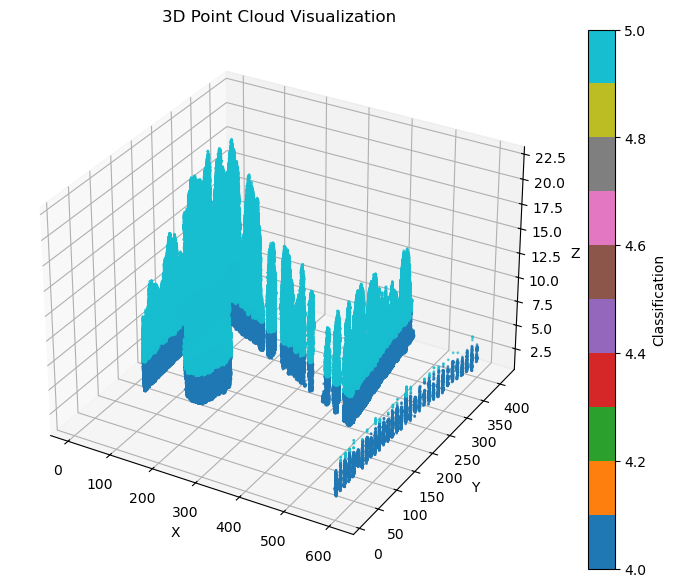

(<Figure size 1000x700 with 2 Axes>,
 <Axes3D: title={'center': '3D Point Cloud Visualization'}, xlabel='X', ylabel='Y', zlabel='Z'>)

In [16]:
delete_classes = [1,2, 6, 7, 9, 11, 12, 17]
#standard Las classes:
# 1 = unclassified
# 2 = ground
# 3 = low vegetation
# 4 = medium vegetation
# 5 = high vegetation
# 6 = building
# 7 = low vegetation
# 9 = water
# 11 = rail
# 12 = road
# 17 = bridge

# Filter out points with specified classifications
filtered_df = df[~df['Classification'].isin(delete_classes)]
#how many points were deleted?
num_deleted = len(df) - len(filtered_df)
print(f"Deleted {num_deleted} points with classifications {delete_classes}")
#total number of points after filtering
print(f"Total points after filtering: {len(filtered_df)}")
# Visualize the filtered point cloud
visualize_pointcloud(filtered_df, show_head=False)

## Remove folliage <5m

In [17]:
h_limit = 5

# Filter out points below the height limit (z)
filtered_df = filtered_df[filtered_df['Z'] >= h_limit]

# Optional Additional removal of trees and folliage
Run the cell below, if you are happy with the results proceed to finding treetops. Otherwise use the subsequent cell to remove more trees.

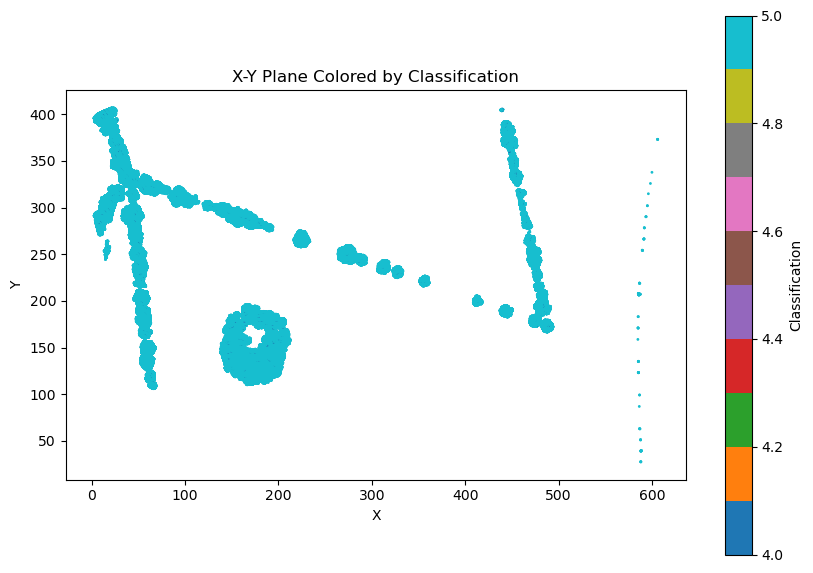

In [18]:
#XY plane plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(filtered_df['X'], filtered_df['Y'], 
                      s=1, c=filtered_df['Classification'], 
                      cmap='tab10',
                      marker='o')
plt.colorbar(scatter, label='Classification')
ax.set_title('X-Y Plane Colored by Classification')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
plt.show()


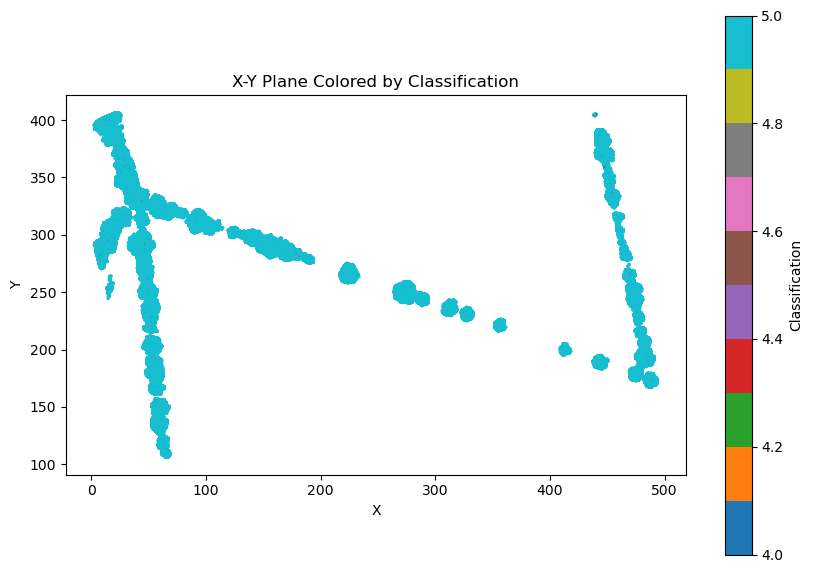

In [19]:
#remove area of circle
center_x, center_y = 170, 155
radius = 50
distance_from_center = np.sqrt((filtered_df['X'] - center_x)**2 + (filtered_df['Y'] - center_y)**2)
filtered_df = filtered_df[distance_from_center > radius]
filtered_df = filtered_df[filtered_df['X'] < 550]  # also remove points with X > 300 to focus on the area of interest

#XY plane plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(filtered_df['X'], filtered_df['Y'], 
                      s=1, c=filtered_df['Classification'], 
                      cmap='tab10',
                      marker='o')
plt.colorbar(scatter, label='Classification')
ax.set_title('X-Y Plane Colored by Classification')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
plt.show()

# Tree top detection and counting

In [20]:
def adaptive_radius(z, min_r=1.0, max_r=5.0):
    return np.clip(0.1 * z + 1.5, min_r, max_r)  # smaller windows = more tops detected

def find_treetops_fast(pointcloud_df, min_height=2.0, top_percentile=0.90):
    trees = pointcloud_df[pointcloud_df['Z'] > min_height].copy().reset_index(drop=True)
    
    # Only keep points in the top 10% of height
    z_threshold = trees['Z'].quantile(top_percentile)
    candidates = trees[trees['Z'] >= z_threshold].reset_index(drop=True)
    print(f"Reduced from {len(trees)} to {len(candidates)} candidate points")
    
    points_xy = candidates[['X', 'Y']].values
    points_z = candidates['Z'].values
    
    # Use lidR matching formula
    radii = adaptive_radius(points_z)
    
    bt = BallTree(points_xy)
    max_radius = radii.max()
    
    print("Querying BallTree...")
    all_neighbors = bt.query_radius(points_xy, r=max_radius)
    
    is_treetop = np.zeros(len(candidates), dtype=bool)
    for i, neighbors in enumerate(tqdm(all_neighbors, desc="Finding treetops")):
        dists = np.sqrt(((points_xy[neighbors] - points_xy[i]) ** 2).sum(axis=1))
        adaptive_neighbors = neighbors[dists <= radii[i]]
        if points_z[i] == points_z[adaptive_neighbors].max():
            is_treetop[i] = True
    
    return candidates[is_treetop].reset_index(drop=True)

treetops_df = find_treetops_fast(filtered_df, min_height=1.5, top_percentile=0.5)
print(f"Identified {len(treetops_df)} treetops.")

Reduced from 1041440 to 520755 candidate points
Querying BallTree...


Finding treetops: 100%|██████████| 520755/520755 [01:07<00:00, 7765.44it/s] 


Identified 105 treetops.


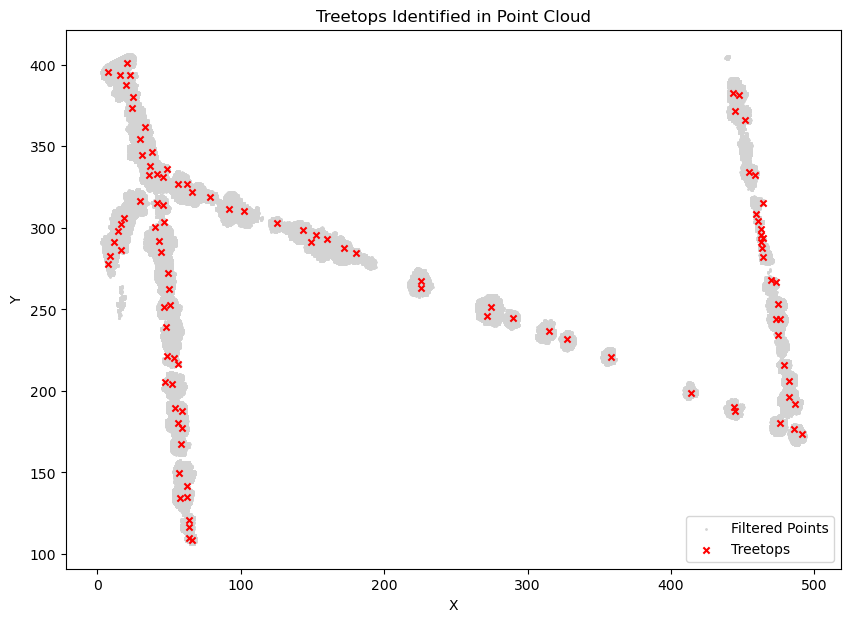

In [21]:
#fig1, ax1 = visualize_pointcloud(filtered_df, show_head=False)
#fig2, ax2 = visualize_pointcloud(treetops_df, show_head=False)

#combined plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered_df['X'], filtered_df['Y'], s=1, c='lightgray', marker='o', label='Filtered Points')
ax.scatter(treetops_df['X'], treetops_df['Y'], s=20, c='red', marker='x', label='Treetops')
ax.set_title('Treetops Identified in Point Cloud')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

# Segmentation

Given the number of trees as input, do instance segmentation

In [22]:
method = 'kmeans'
tree_count_estimate = len(treetops_df)
use_guess_positions = True

def segment_pointcloud(pointcloud_df, num_trees, method='kmeans', initial_positions=None):
    points_xy = pointcloud_df[['X', 'Y']].values
    
    if method == 'kmeans':
        if initial_positions is not None:
            kmeans = KMeans(n_clusters=num_trees, 
                            init=initial_positions,  # use treetop positions as initial centroids
                            n_init=1, # don't run multiple times if we provide initial positions, but do run multiple times if we don't to find better centroids
                            random_state=42)
        else:
            kmeans = KMeans(n_clusters=num_trees, 
                            n_init=1,
                            random_state=42)
    
    pointcloud_df['tree_id'] = kmeans.fit_predict(points_xy)
    return pointcloud_df

# Prepare initial positions from treetop detection
initial_positions = treetops_df[['X', 'Y']].values if use_guess_positions else None

time_start = time.time()
segmented_df = segment_pointcloud(filtered_df, 
                                   num_trees=tree_count_estimate, 
                                   method='kmeans',
                                   initial_positions=initial_positions)
time_end = time.time()
runtime = time_end - time_start

print('=== Segmentation Results ===')
print(f'Method:              {method}')
print(f'Number of trees:     {tree_count_estimate}')
print(f'Used treetop guess:  {use_guess_positions}')
print(f'Runtime:             {round(runtime, 2)} seconds')
#TODO: compare with ground truth when available

=== Segmentation Results ===
Method:              kmeans
Number of trees:     105
Used treetop guess:  True
Runtime:             1.01 seconds


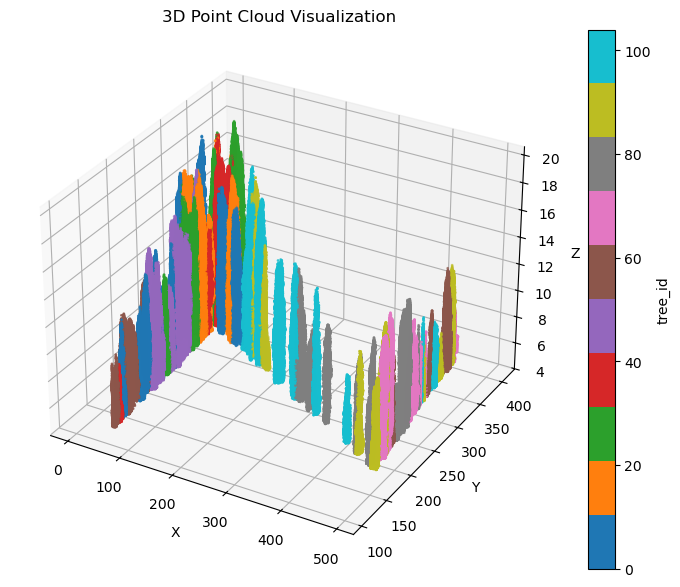


=== Tree Crown Statistics ===
         Crown Area (m²)  Max Circle Area (m²)  Max Circle Radius (m)  Point Count  height
Tree ID                                                                                   
0                  97.61                 42.47                   3.68        13391  12.519
1                  72.65                 45.55                   3.81        10171  12.519
2                 198.28                145.30                   6.80         9295  12.519
3                 137.47                 96.16                   5.53         9326  12.519
4                 102.76                 66.66                   4.61         5562  12.519
5                  85.51                 52.81                   4.10        10379  12.519
6                 183.32                121.55                   6.22        27731  12.519
7                  59.83                 46.50                   3.85         5846  12.519
8                 112.02                 88.25             

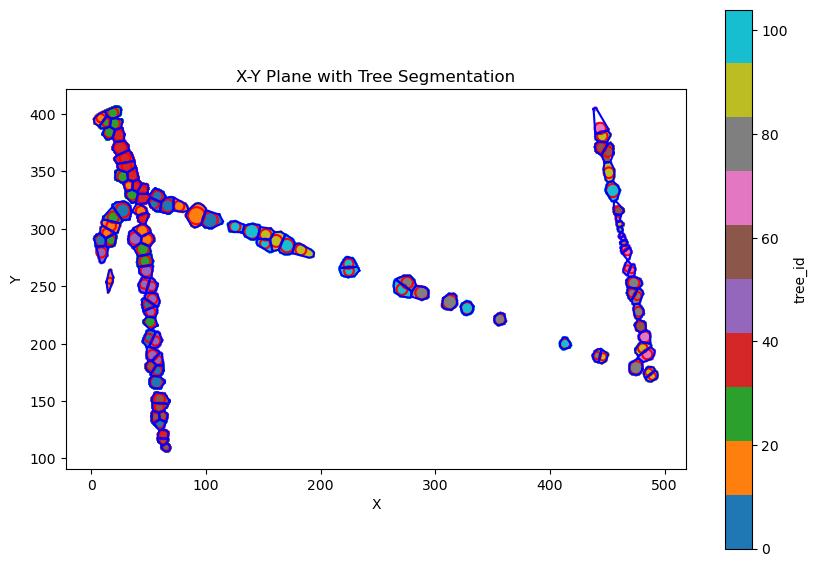

In [23]:
visualize_pointcloud(segmented_df, labels="tree_id", show_head=False)
trees_spec_df=X_Y_plane(segmented_df, area_calucation=True, height_caluation=True)


         Crown Area (m²)  Max Circle Area (m²)  Max Circle Radius (m)  Point Count  height  Max Height (m)        Species  Est. DBH (cm)  Above Threshold
Tree ID                                                                                                                                                  
0                  97.61                 42.47                   3.68        13391  12.519           14.77  Norway Spruce          12.31            False
1                  72.65                 45.55                   3.81        10171  12.519           14.22  Norway Spruce          11.10            False
2                 198.28                145.30                   6.80         9295  12.519           15.16  Norway Spruce          15.24             True
3                 137.47                 96.16                   5.53         9326  12.519           15.15  Norway Spruce          13.74            False
4                 102.76                 66.66                   4.61       

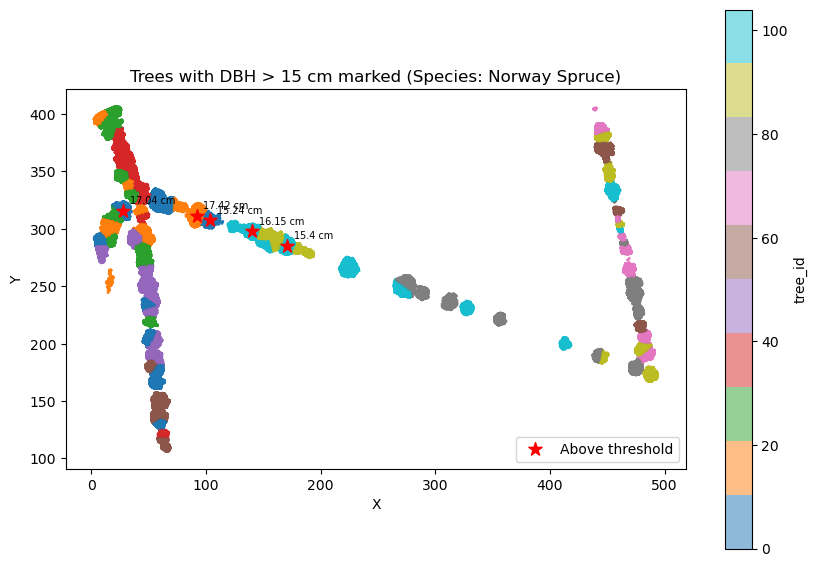

In [24]:
# Allometric coefficients for Diameter at Breast Height (DBH) estimation
# Source: Petersson & Ståhl (2006), Näslund (1947)
# Formula: DBH = a * Height^b * Crown_Area^c

SPECIES_COEFFICIENTS = {
    'Norway Spruce': {'a': 0.816, 'b': 0.528, 'c': 0.282},  # Picea abies
    'Scots Pine':    {'a': 0.723, 'b': 0.572, 'c': 0.311},  # Pinus sylvestris
    'Birch':         {'a': 0.654, 'b': 0.481, 'c': 0.267},  # Betula spp.
}

def estimate_dbh(crown_area, height, species='Norway Spruce'):
    if species not in SPECIES_COEFFICIENTS:
        raise ValueError(f"Species must be one of: {list(SPECIES_COEFFICIENTS.keys())}")
    c = SPECIES_COEFFICIENTS[species]
    return c['a'] * (height ** c['b']) * (crown_area ** c['c'])

# --- Parameters ---
species = 'Norway Spruce'  # change to your site species
threshold = 15             # cm DBH threshold

# --- Add columns to previous results ---
tree_max_height = segmented_df.groupby('tree_id')['Z'].max()
trees_spec_df['Max Height (m)']  = tree_max_height.round(2)
trees_spec_df['Species']         = species
trees_spec_df['Est. DBH (cm)']   = trees_spec_df.apply(
    lambda row: estimate_dbh(row['Crown Area (m²)'], row['Max Height (m)'], species),
    axis=1
).round(2)
trees_spec_df['Above Threshold'] = trees_spec_df['Est. DBH (cm)'] > threshold

print(trees_spec_df.to_string())
trees_spec_df.to_csv('tree_metrics.csv', index=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(segmented_df['X'], segmented_df['Y'],
                     s=1, c=segmented_df['tree_id'],
                     cmap='tab10', marker='o', alpha=0.5)
plt.colorbar(scatter, label='tree_id')

# Overlay trees above threshold
for tree_id, row in trees_spec_df[trees_spec_df['Above Threshold']].iterrows():
    group = segmented_df[segmented_df['tree_id'] == tree_id]
    center_x = group['X'].mean()
    center_y = group['Y'].mean()
    ax.scatter(center_x, center_y,
               s=100, c='red', marker='*', zorder=5,
               label='Above threshold' if tree_id == trees_spec_df[trees_spec_df['Above Threshold']].index[0] else "")
    ax.annotate(f"{row['Est. DBH (cm)']} cm",
                (center_x, center_y),
                textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.legend()
ax.set_title(f'Trees with DBH > {threshold} cm marked (Species: {species})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
plt.show()